# Haltungserkennung in politischen Kommentaren

**Fachhochschule Südwestfalen** · Natural Language Processing

Yurii Dobrytsia, 30518764

28.09.2026

## Inhaltsverzeichnis

1. Problemstellung und Daten
2. Stand der Technik
3. Lösung mit Evaluation
4. Kritische Reflexion und Fazit
5. Literatur

## 1 Problemstellung und Daten

### 1.1 Problem und Forschungsfrage

Vor Wahlen in der Schweiz beantworten viele Kandidierende auf der Online-Wahlhilfe smartvote politische Sachfragen mit *ja*, *eher ja*, *eher nein* oder *nein* und können ihre Antwort in einem kurzen Kommentar begründen (Vamvas und Sennrich, 2020). Haltungserkennung, im Englischen Stance Detection, bestimmt aus einem Text, ob die schreibende Person ein Ziel befürwortet, ablehnt oder neutral bleibt (Mohammad et al., 2016); der aus smartvote gewonnene Datensatz x-stance kennt nur die ersten beiden Fälle. Wer politische Kommentare in großer Zahl auswertet, etwa eine Redaktion oder ein Verband, muss diese Entscheidung automatisieren, und ein Fehler schreibt einer Person eine Position zu, die sie nicht vertritt.

Schwierig ist die Aufgabe aus 2 Gründen. Die Haltung steht selten wörtlich im Kommentar, weil die Plattform die Antwort ohnehin neben dem Text anzeigt (Vamvas und Sennrich, 2020). Und jede Wahl bringt neue Fragen ohne Trainingsbeispiele, sodass ein brauchbares Modell auch bei Fragen und Themen urteilen muss, die es nie gesehen hat.

Im Herbst 2026 ziehe ich in die Schweiz, und smartvote wird eine der Quellen sein, über die ich die Positionen in einem für mich neuen politischen System kennenlerne. Dazu kommt ein fachlicher Bezug. Ich stamme aus einem landwirtschaftlichen Familienbetrieb in der Ukraine, und unter den Fragen des Datensatzes finden sich agrarpolitische, etwa zur Verlängerung des Moratoriums für gentechnisch veränderte Pflanzen und Tiere oder zu höheren Direktzahlungen für die Bio-Produktion. Aus der Praxis weiß ich, dass zwischen einem klaren Ja und einem vorsichtigen Eher-Ja oft eine ganze Liste von Bedingungen steht. Genau diese Zwischentöne fasst der Datensatz zu 2 Labels zusammen.

**Um wie viele Prozentpunkte im Makro-F1 übertrifft ein feinabgestimmtes GBERT eine TF-IDF-SVM bei Kommentaren zu bekannten Fragen, und welcher Anteil dieses Vorsprungs bleibt bei unbekannten Fragen und unbekannten Themen erhalten?**

Gemessen wird auf den 3 offiziellen deutschen Testsätzen von x-stance mit der dort vorgegebenen Metrik, dem Mittel der F1-Werte für FAVOR und AGAINST. Verglichen werden GBERT (Chan et al., 2020), ein deutsches Sprachmodell vom Typ BERT (Bidirectional Encoder Representations from Transformers), und eine lineare Support Vector Machine (SVM) auf TF-IDF-Merkmalen (Term Frequency, Inverse Document Frequency). Beide trainieren auf derselben Stichprobe, und keine Entscheidung stützt sich auf einen Testsatz. Bezugsgröße ist der Vorsprung auf bekannten Fragen; der erhaltene Anteil ist der Vorsprung auf einem entfernteren Testsatz, geteilt durch diese Bezugsgröße. Eine Mehrheitsklasse bildet die Untergrenze, die stärksten veröffentlichten Systeme aus Abschnitt 2 dienen als obere Referenz.

### 1.2 Datensatz

Vamvas und Sennrich (2020) haben x-stance aus kommunalen, kantonalen und nationalen Wahlen der Jahre 2011 bis 2020 gewonnen, mit Kommentaren auf Deutsch, Französisch und Italienisch. Die Antworten *ja* und *eher ja* bilden das Label FAVOR, *eher nein* und *nein* das Label AGAINST; unter anderem wurden zu kurze Kommentare und solche mit Links entfernt. Von Hand annotiert wurde nichts, das Label ist die eigene Antwort der Person. Validierung und Test stammen nur aus nationalen Wahlen.

Diese Arbeit nutzt den deutschen Teil, weil GBERT ein deutsches Modell ist. Grundlage ist das unveränderte Archiv `xstance-data-v1.0.zip` der Autoren im Ordner `data/`, lizenziert von smartvote unter CC BY-NC 4.0. Jede Zeile enthält unter anderem Frage, Kommentar, Label, die ursprüngliche Antwortstufe `numerical_label`, das Thema und eine gehashte Kennung der Person. Die folgenden 3 Codezellen installieren und importieren die Bibliotheken, setzen den Seed und protokollieren die Versionen; scikit-learn liefert Vergleichsverfahren und Metriken (Pedregosa et al., 2011), transformers den Tokenizer und das Modell von GBERT (Wolf et al., 2020).

In [1]:
%%capture
%pip install pandas==3.0.6 numpy==2.4.6 scipy==1.17.1 scikit-learn==1.9.1 matplotlib==3.11.2 transformers==4.57.6

In [2]:
import json, re, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.pipeline import make_union
from sklearn.svm import LinearSVC
from transformers import AutoTokenizer

RANDOM_STATE = 1977  # ein Seed für SVM und Bootstrap, gleich wie in train_gbert.py
DATA = Path('data')
CACHE = DATA / 'cache'
LABELS = ['AGAINST', 'FAVOR']  # Reihenfolge wie in scikit-learn und im gbert-Cache
TESTS = {'new_comments': 'bekannte Fragen', 'new_questions': 'unbekannte Fragen', 'new_topics': 'unbekannte Themen'}

In [3]:
import sklearn, scipy, matplotlib, transformers
import platform
print(f'Python {platform.python_version()}, pandas {pd.__version__}, numpy {np.__version__}, scipy {scipy.__version__}')
print(f'scikit-learn {sklearn.__version__}, matplotlib {matplotlib.__version__}, transformers {transformers.__version__}')

Python 3.11.15, pandas 3.0.6, numpy 2.4.6, scipy 1.17.1
scikit-learn 1.9.1, matplotlib 3.11.2, transformers 4.57.6


Die Daten werden direkt aus dem Archiv gelesen und auf `language == 'de'` gefiltert. `new_comments` enthält neue Antworten zu bekannten Fragen, `new_questions` neue Fragen aus bekannten Themen und `new_topics` Fragen aus den Themen Gesundheitswesen und Politisches System, die im Training fehlen (Vamvas und Sennrich, 2020); im Text heißen diese Testsätze bekannte Fragen, unbekannte Fragen und unbekannte Themen. Die Zelle lädt außerdem die Trainingsstichprobe, die `train_gbert.py` gezogen hat.

In [4]:
def read_german(name):
    with zipfile.ZipFile(DATA / 'xstance-data-v1.0.zip') as z:  # Originalarchiv, unverändert
        return pd.read_json(z.open(name), lines=True).query("language == 'de'").reset_index(drop=True)

train_full = read_german('train.jsonl')
test_all = read_german('test.jsonl')
splits = {'dev': read_german('valid.jsonl')}
splits.update({s: test_all[test_all['test_set'] == f'{s}_defr'].reset_index(drop=True) for s in TESTS})
sub_ids = {int(i) for i in (CACHE / 'train_subsample_ids.txt').read_text().split()}
train = train_full[train_full['id'].isin(sub_ids)].reset_index(drop=True)  # Stichprobe aus train_gbert.py
chars = pd.concat([train_full, splits['dev'], test_all])['comment'].str.len()
print(f'train_full {len(train_full):,}, Stichprobe {len(train):,} ({len(train) / len(train_full):.3f}), '
      f'Fragen in der Stichprobe {train.question_id.nunique()} von {train_full.question_id.nunique()}, '
      f'Kommentarlänge {chars.min()} bis {chars.max()} Zeichen')

train_full 33,850, Stichprobe 16,911 (0.500), Fragen in der Stichprobe 160 von 160, Kommentarlänge 50 bis 500 Zeichen


GBERT trainiert aus Zeitgründen nicht auf allen 33.850 deutschen Paaren aus Frage und Kommentar, sondern auf 16.911, einem Anteil von 0,500; Abschnitt 3.4 belegt die Rechenzeit. Die Stichprobe ist je Frage und Label geschichtet und behält alle 160 Fragen. Die SVM trainiert auf derselben Stichprobe, damit der Modellvergleich nicht an der Datenmenge hängt. Die Kommentare sind 50 bis 500 Zeichen lang; die Untergrenze stammt aus der Filterung durch die Datensatzautoren, die Obergrenze aus smartvote.

In [5]:
def class_counts(df):
    n = df['label'].value_counts()
    return {'AGAINST': n.get('AGAINST', 0), 'FAVOR': n.get('FAVOR', 0), 'gesamt': len(df),
            'Anteil FAVOR': round(n.get('FAVOR', 0) / len(df), 3),
            'Fragen': df['question_id'].nunique(), 'Themen': df['topic'].nunique()}

table = {'train (voll)': train_full, 'train (Stichprobe)': train, **splits}
counts = pd.DataFrame({name: class_counts(df) for name, df in table.items()}).T
counts.astype({'AGAINST': int, 'FAVOR': int, 'gesamt': int, 'Fragen': int, 'Themen': int})

,AGAINST,FAVOR,gesamt,Anteil FAVOR,Fragen,Themen
train (voll),17130,16720,33850,0.494,160,10
train (Stichprobe),8555,8356,16911,0.494,160,10
dev,1451,1420,2871,0.495,150,10
new_comments,1757,1722,3479,0.495,150,10
new_questions,1343,1800,3143,0.573,14,9
new_topics,2782,2487,5269,0.472,20,2


Die Klassen sind im Training fast ausgeglichen. Der Anteil von FAVOR beträgt 0,494, und die Stichprobe übernimmt ihn. Auf den unbekannten Fragen steigt er auf 0,573, auf den unbekannten Themen liegt er bei 0,472. Die Mehrheitsklasse der deutschen Trainingsdaten ist AGAINST mit 17.130 zu 16.720 Paaren. Der Testsatz mit unbekannten Fragen umfasst nur 14 Fragen, der mit unbekannten Themen 20 Fragen aus 2 Themen, sodass dort einzelne Fragen viel Gewicht haben.

Die Zählungen lassen sich mit Tabelle 2 und Abschnitt 3.3 bei Vamvas und Sennrich (2020) abgleichen. Die Zelle stellt die dort gedruckten deutschen Werte den veröffentlichten Dateien gegenüber.

In [6]:
printed = {'Validierung': 3479, 'bekannte Fragen': 2871, 'unbekannte Fragen': 3143,  # Tabelle 2, DE, wie gedruckt
           'unbekannte Themen': 5269, 'Fragen in unbekannte Fragen': 16}  # 16 laut Abschnitt 3.3 des Papers
files = {'Validierung': len(splits['dev']), **{TESTS[s]: len(splits[s]) for s in TESTS},
         'Fragen in unbekannte Fragen': splits['new_questions']['question_id'].nunique()}
pd.DataFrame({'Vamvas & Sennrich 2020': printed, 'veröffentlichte Dateien': files})

,Vamvas & Sennrich 2020,veröffentlichte Dateien
Validierung,3479,2871
bekannte Fragen,2871,3479
unbekannte Fragen,3143,3143
unbekannte Themen,5269,5269
Fragen in unbekannte Fragen,16,14


Die Paarzahlen stimmen überein, ihre Beschriftung nicht. Tabelle 2 führt 3.479 Paare unter Valid und 2.871 unter Test, die Dateien enthalten dagegen 2.871 Validierungs- und 3.479 Testpaare. Die Beschriftung im Artikel ist offenbar vertauscht, und diese Arbeit folgt den Dateien; auch Schick und Schütze (2021) nennen 3.479 deutsche Testpaare. Abschnitt 3.3 des Artikels spricht außerdem von 16 ausgewählten Fragen für den Testsatz mit unbekannten Fragen, die Dateien enthalten 14, und die gedruckten 3.143 Paare entsprechen genau diesen 14 Fragen.

In [7]:
scale = {0: 'nein', 25: 'eher nein', 75: 'eher ja', 100: 'ja'}
answers = pd.DataFrame({name: df['numerical_label'].map(scale).value_counts(normalize=True)
                        for name, df in {'train (voll)': train_full, **splits}.items()}).T
answers = answers[list(scale.values())].round(3)
answers['Anteil schwach (eher)'] = answers['eher nein'] + answers['eher ja']
answers

numerical_label,nein,eher nein,eher ja,ja,Anteil schwach (eher)
train (voll),0.314,0.192,0.228,0.266,0.420
dev,0.310,0.196,0.232,0.262,0.428
new_comments,0.306,0.199,0.220,0.275,0.419
new_questions,0.238,0.190,0.251,0.322,0.441
new_topics,0.325,0.203,0.209,0.263,0.412


Die ursprüngliche Antwortstufe ist in allen Teilen ähnlich verteilt. Im Training beruht ein Anteil von 0,420 der Paare auf *eher ja* oder *eher nein*, in Validierung und Tests sind es 0,412 bis 0,441. Diese Paare tragen dasselbe Label wie klare Antworten, obwohl die Person nur eine Tendenz angab. Vamvas und Sennrich (2020) begründen die Zusammenfassung mit Konsistenz und Vergleichbarkeit mit früheren Datensätzen; Abschnitt 3.6 misst, was sie für die Fehler bedeutet.

### 1.3 Prüfung der Testsätze

Bevor ein Modell trainiert wird, prüft dieser Abschnitt, wie weit die Testsätze vom Training abweichen. Untersucht werden die Labelverteilung mit einem Chi-Quadrat-Test im Vergleich zu den vollständigen Trainingsdaten, die Kommentarlänge, Überschneidungen von Personen und Texten, explizite Signalwörter und die Kürzung durch die maximale Sequenzlänge von GBERT.

In [8]:
rows = {}
for s, df in splits.items():
    ct = pd.crosstab(pd.concat([train_full['label'], df['label']]),
                     ['train'] * len(train_full) + [s] * len(df))
    chi2, p, _, _ = chi2_contingency(ct)
    words = df['comment'].str.split().str.len()
    rows[s] = {'Anteil FAVOR': round((df['label'] == 'FAVOR').mean(), 3), 'Chi2 vs. train': round(chi2, 1),
               'p-Wert': f'{p:.2g}', 'Wörter Mittel': round(words.mean(), 1), 'Wörter Median': words.median()}
rows['train (voll)'] = {'Anteil FAVOR': round((train_full['label'] == 'FAVOR').mean(), 3),
                        'Wörter Mittel': round(train_full['comment'].str.split().str.len().mean(), 1),
                        'Wörter Median': train_full['comment'].str.split().str.len().median()}
pd.DataFrame(rows).T

,Anteil FAVOR,Chi2 vs. train,p-Wert,Wörter Mittel,Wörter Median
dev,0.495,0.0,0.96,25.2,21.0
new_comments,0.495,0.0,0.92,22.7,19.0
new_questions,0.573,71.0,3.5e-17,23.1,19.0
new_topics,0.472,8.7,0.0032,24.0,20.0
train (voll),0.494,NaN,NaN,24.4,20.0


Validierung und bekannte Fragen folgen der Labelverteilung des Trainings (p = 0,96 und 0,92). Die unbekannten Fragen weichen deutlich ab (Chi-Quadrat 71,0, p = 3,5 · 10⁻¹⁷), die unbekannten Themen schwächer (8,7, p = 0,0032), weil wenige neue Fragen ihre eigene Verteilung mitbringen. Der Test behandelt die Paare als unabhängig, obwohl Paare derselben Frage zusammenhängen, und überschätzt daher die Sicherheit; an der Größe der Abweichung ändert das nichts. Ein Modell, das die Klassen im Verhältnis des Trainings vorhersagt, kann dort schon deshalb verlieren. Die Kommentare sind kurz, im Mittel 22,7 bis 25,2 Wörter bei einem Median von 19 bis 21.

In [9]:
train_authors = set(train_full['author'])
train_texts = set(train_full['comment'].str.strip().str.lower())
overlap = {}
for s, df in splits.items():
    overlap[s] = {'Zeilen': len(df),
                  'Autor auch in train': int(df['author'].isin(train_authors).sum()),
                  'Kommentar wörtlich in train': int(df['comment'].str.strip().str.lower().isin(train_texts).sum()),
                  'Fragen auch in train': int(df['question_id'].isin(train_full['question_id']).sum())}
dup = train_full.assign(t=train_full['comment'].str.strip().str.lower()).groupby('t')['label'].agg(['size', 'nunique'])
same_q = train_full.assign(t=train_full['comment'].str.strip().str.lower()).groupby(['t', 'question_id'])['label'].nunique()
print(f'train: {int((dup["size"] > 1).sum())} Kommentartexte mehrfach, {int((dup["nunique"] > 1).sum())} davon mit beiden Labels, '
      f'{same_q[same_q > 1].index.get_level_values("t").nunique()} davon unter derselben Frage')
pd.DataFrame(overlap).T

train: 1630 Kommentartexte mehrfach, 47 davon mit beiden Labels, 39 davon unter derselben Frage


,Zeilen,Autor auch in train,Kommentar wörtlich in train,Fragen auch in train
dev,2871,0,4,2871
new_comments,3479,0,2,3479
new_questions,3143,2476,0,0
new_topics,5269,4221,0,0


Die Testsätze grenzen sich unterschiedlich vom Training ab. In der Validierung und bei den bekannten Fragen kommt keine Person aus dem Training vor, alle Fragen dagegen schon. Bei unbekannten Fragen und Themen ist es umgekehrt, dort stammen 2.476 von 3.143 und 4.221 von 5.269 Paaren von Personen, die auch im Training vertreten sind. Dubletten zum Training, bei denen Groß- und Kleinschreibung nicht beachtet wird, sind mit 4, 2, 0 und 0 Fällen vernachlässigbar. Innerhalb des Trainings kommen 1.630 Kommentartexte mehrfach vor, 47 davon mit beiden Labels, darunter 39 unter derselben Frage. Derselbe Wortlaut trägt dort einmal FAVOR und einmal AGAINST, das Label hängt also nicht allein am Text.

In [10]:
cue = re.compile(r'^\W*(ja|nein)\b', re.IGNORECASE)  # Kommentar beginnt mit Ja oder Nein

def cue_word(df):
    return df['comment'].str.extract(cue, expand=False).str.lower()

cues = {}
for name, df in {'train (voll)': train_full, **splits}.items():
    w = cue_word(df)
    cues[name] = {'beginnt mit Ja': int((w == 'ja').sum()), 'davon FAVOR': int(((w == 'ja') & (df['label'] == 'FAVOR')).sum()),
                  'beginnt mit Nein': int((w == 'nein').sum()), 'davon AGAINST': int(((w == 'nein') & (df['label'] == 'AGAINST')).sum()),
                  'Anteil mit Signalwort': round(w.notna().mean(), 3)}
pd.DataFrame(cues).T.astype({k: int for k in ['beginnt mit Ja', 'davon FAVOR', 'beginnt mit Nein', 'davon AGAINST']})

,beginnt mit Ja,davon FAVOR,beginnt mit Nein,davon AGAINST,Anteil mit Signalwort
train (voll),578,539,371,368,0.028
dev,43,42,44,44,0.030
new_comments,59,51,38,38,0.028
new_questions,67,61,19,18,0.027
new_topics,96,88,59,59,0.029


Die Exploration passt dazu, dass die Haltung selten ausdrücklich im Text steht, auch wenn sie nur ein einfaches Signal prüft. Der Anteil der Kommentare, die mit Ja oder Nein beginnen, liegt nur bei 0,027 bis 0,030, und diese Signalwörter sind fast eindeutig. Im Training tragen 539 von 578 Ja-Kommentaren das Label FAVOR und 368 von 371 Nein-Kommentaren das Label AGAINST. Für die übrigen Kommentare fehlt zumindest dieses Signal, und die Haltung muss meist aus dem Inhalt und aus dem Bezug zur Frage erschlossen werden. Vamvas und Sennrich (2020) nennen diese Implizitheit selbst als mögliche Schwäche des Datensatzes.

In [11]:
tokenizer = AutoTokenizer.from_pretrained('deepset/gbert-base')
MAX_LEN = 128  # wie in train_gbert.py

def pair_lengths(df):
    enc = tokenizer(df['question'].tolist(), df['comment'].tolist())
    return pd.Series([len(ids) for ids in enc['input_ids']])

lengths = {name: pair_lengths(df) for name, df in {'train (Stichprobe)': train, **splits}.items()}
pd.DataFrame({name: {'Tokens Mittel': round(l.mean(), 1), 'Tokens p95': l.quantile(0.95),
                     'Tokens max': l.max(), f'über {MAX_LEN}': int((l > MAX_LEN).sum()),
                     'Anteil gekürzt': round((l > MAX_LEN).mean(), 4)} for name, l in lengths.items()}).T.astype({'Tokens max': int, f'über {MAX_LEN}': int})

,Tokens Mittel,Tokens p95,Tokens max,über 128,Anteil gekürzt
train (Stichprobe),62.2,111.0,189,225,0.0133
dev,62.4,111.5,152,45,0.0157
new_comments,59.1,104.0,160,23,0.0066
new_questions,55.8,100.0,159,12,0.0038
new_topics,61.0,106.0,159,39,0.0074


GBERT liest Frage und Kommentar als Paar und kürzt bei mehr als 128 Tokens nur den Kommentar. Im Mittel sind die Paare 55,8 bis 62,4 Tokens lang. Gekürzt werden 225 Paare der Trainingsstichprobe, ein Anteil von 0,0133, in den Testsätzen sind es 0,0038 bis 0,0074. Die Grenze wurde vorab festgelegt, um die Rechenzeit langer Batches auf dem Hauptprozessor (CPU) zu begrenzen, und betrifft so wenige Paare, dass der Unterschied zu den 256 Tokens bei Schick und Schütze (2021) und Vamvas et al. (2023) kaum ins Gewicht fallen dürfte.

### 1.4 Was die Exploration festlegt

5 Befunde bestimmen das weitere Vorgehen.

1. Die Klassen sind im Training fast ausgeglichen (0,494 FAVOR). Bewertet wird pro Klasse mit Precision, Recall und F1 und zusammenfassend mit dem offiziellen Makro-F1 (Abschnitt 3.1).
2. Die unbekannten Fragen verschieben die Verteilung auf 0,573 FAVOR, sodass der Wert der Mehrheitsklasse dort an der gewählten Klasse hängt (Abschnitt 3.2).
3. Mit Ja oder Nein beginnt nur ein Anteil von 0,027 bis 0,030 der Kommentare. Beide Lernverfahren erhalten deshalb Frage und Kommentar (Abschnitte 3.3 und 3.4).
4. In den Testsätzen beruht ein Anteil von 0,412 bis 0,441 der Paare auf einer abgeschwächten Antwort. Die Fehleranalyse ordnet Fehler nach der Antwortstufe (Abschnitt 3.6).
5. Bei unbekannten Fragen und Themen ist keine Frage bekannt, die meisten Personen aber schon. Der Abstand zwischen den Testsätzen zeigt deshalb die Folgen eines neuen Ziels und unterschätzt sie womöglich, was Abschnitt 3.6 prüft.

## 2 Stand der Technik

Haltungserkennung ist spätestens seit Aufgabe 6 des Evaluationswettbewerbs SemEval-2016 ein etabliertes Klassifikationsproblem, bewertet mit dem Mittel der F1-Werte für FAVOR und AGAINST (Mohammad et al., 2016). Im überwachten Teil übertraf dort kein teilnehmendes System eine je Ziel trainierte SVM mit Wort- und Zeichen-n-Grammen, die Mitglieder des Veranstalterteams außer Konkurrenz berichteten. x-stance überträgt die Aufgabe auf viele Ziele und 3 Sprachen (Vamvas und Sennrich, 2020). Weil die in der Aufgabenstellung genannte Plattform Papers with Code eingestellt wurde, stammen die folgenden Werte aus dem Artikel zum Datensatz und aus Arbeiten, die x-stance selbst auswerten; jede Zahl wurde in der Originalquelle nachgeprüft. 2 Linien lassen sich unterscheiden.

Die erste Linie bilden die Referenzsysteme der Datensatzautoren. Auf den deutschen Testsätzen erreicht eine über Deutsch und Französisch gebildete Mehrheitsklasse 33,1, 36,4 und 32,1 für bekannte Fragen, unbekannte Fragen und unbekannte Themen, fastText auf Frage und Kommentar 69,9, 62,0 und 63,1 und das mehrsprachige M-BERT als Satzpaar-Klassifikator 76,8, 68,5 und 68,9. M-BERT wurde auf Deutsch und Französisch gemeinsam trainiert, mit bis zu 512 Tokens und einer Rastersuche, die nach Validierungs-Accuracy auswählte, und verliert beim Wechsel zu unbekannten Fragen und Themen 8,3 und 7,9 Punkte. Egli et al. (2023) berichten in einem Preprint von einer SVM auf gehashten Merkmalen mit Standardeinstellungen, die von 61,49 bei bekannten Fragen auf 37,49 und 34,70 fällt, praktisch das Niveau einer Mehrheitsklasse; ob die Frage in ihre Merkmale einging, bleibt offen.

Die zweite Linie bilden vortrainierte Modelle nach 2020. Schick und Schütze (2021) trainieren das mehrsprachige XLM-R base (XLM-RoBERTa) allein auf deutschen Daten und berichten für bekannte Fragen 63,2 mit 4.000 Paaren und 76,6 mit allen 33.850, jeweils als Mittel aus 3 Läufen. Ihr Verfahren PET (Pattern-Exploiting Training), das die Klassifikation als Lückentext formuliert, erreicht 77,9; zusammen mit den französischen Daten kommt XLM-R auf 77,6 und PET auf 78,8, die höchsten gefundenen Werte für bekannte Fragen. Auf unbekannten Themen liegt SwissBERT vorn, ein auf Schweizer Nachrichtentexten weitertrainiertes Modell mit Sprachadaptern (Vamvas et al., 2023). Die veröffentlichte Variante erreicht auf bekannten Fragen und unbekannten Themen 78,3 und 74,0 als Mittel über 10 Seeds mit Standardabweichungen von 0,4 und 0,6, XLM-R im selben Aufbau 76,9 und 73,0 mit 0,8 und 1,3. Diese Streuung zwischen Seeds ist der Maßstab für den einzelnen Lauf dieser Arbeit. Die Tabelle fasst alles als Makro-F1 auf der Skala von 0 bis 100 zusammen.

In [12]:
literature = pd.DataFrame([
    ('Mehrheitsklasse (global)', 'Vamvas & Sennrich 2020', 'DE+FR', '', 33.1, 36.4, 32.1),
    ('Mehrheit je Frage', 'Vamvas & Sennrich 2020', 'DE+FR', '', 60.8, None, None),
    ('fastText', 'Vamvas & Sennrich 2020', 'DE+FR, voll', '', 69.9, 62.0, 63.1),
    ('M-BERT', 'Vamvas & Sennrich 2020', 'DE+FR, voll, 512 Tokens', '', 76.8, 68.5, 68.9),
    ('SVM, gehashte Merkmale', 'Egli et al. 2023', 'Sprachen nicht angegeben', '', 61.49, 37.49, 34.70),
    ('XLM-R base, 4.000 Paare', 'Schick & Schütze 2021', 'nur DE, 256 Tokens', 'Mittel 3 Läufe', 63.2, None, None),
    ('XLM-R base', 'Schick & Schütze 2021', 'nur DE, 33.850 Paare, 256 Tokens', 'Mittel 3 Läufe', 76.6, None, None),
    ('PET mit XLM-R base', 'Schick & Schütze 2021', 'nur DE, 33.850 Paare, 256 Tokens', 'Mittel 3 Läufe', 77.9, None, None),
    ('XLM-R base, DE+FR', 'Schick & Schütze 2021', 'DE+FR, 45.640 Paare, 256 Tokens', 'Mittel 3 Läufe', 77.6, None, None),
    ('PET mit XLM-R base, DE+FR', 'Schick & Schütze 2021', 'DE+FR, 45.640 Paare, 256 Tokens', 'Mittel 3 Läufe', 78.8, None, None),
    ('XLM-R base', 'Vamvas et al. 2023', 'voll, Sprachen nicht angegeben, 256 Tokens', '10 Seeds, Std 0.8 / 1.3', 76.9, None, 73.0),
    ('SwissBERT', 'Vamvas et al. 2023', 'voll, Sprachen nicht angegeben, 256 Tokens', '10 Seeds, Std 0.4 / 0.6', 78.3, None, 74.0),
], columns=['System', 'Quelle', 'Training', 'Läufe', 'bekannte Fragen', 'unbekannte Fragen', 'unbekannte Themen'])
literature['Abfall unbekannte Fragen'] = (literature['bekannte Fragen'] - literature['unbekannte Fragen']).round(2)
literature['Abfall unbekannte Themen'] = (literature['bekannte Fragen'] - literature['unbekannte Themen']).round(2)
literature.set_index(['System', 'Quelle']).fillna('')  # leer = in der Quelle nicht berichtet

,,Training,Läufe,bekannte Fragen,unbekannte Fragen,unbekannte Themen,Abfall unbekannte Fragen,Abfall unbekannte Themen
System,Quelle,,,,,,,
Mehrheitsklasse (global),Vamvas & Sennrich 2020,DE+FR,,33.10,36.4,32.1,-3.3,1.0
Mehrheit je Frage,Vamvas & Sennrich 2020,DE+FR,,60.80,,,,
fastText,Vamvas & Sennrich 2020,"DE+FR, voll",,69.90,62.0,63.1,7.9,6.8
M-BERT,Vamvas & Sennrich 2020,"DE+FR, voll, 512 Tokens",,76.80,68.5,68.9,8.3,7.9
"SVM, gehashte Merkmale",Egli et al. 2023,Sprachen nicht angegeben,,61.49,37.49,34.7,24.0,26.79
"XLM-R base, 4.000 Paare",Schick & Schütze 2021,"nur DE, 256 Tokens",Mittel 3 Läufe,63.20,,,,
XLM-R base,Schick & Schütze 2021,"nur DE, 33.850 Paare, 256 Tokens",Mittel 3 Läufe,76.60,,,,
PET mit XLM-R base,Schick & Schütze 2021,"nur DE, 33.850 Paare, 256 Tokens",Mittel 3 Läufe,77.90,,,,
"XLM-R base, DE+FR",Schick & Schütze 2021,"DE+FR, 45.640 Paare, 256 Tokens",Mittel 3 Läufe,77.60,,,,


Für GBERT, das deutsche Modell von Chan et al. (2020), ließ sich kein veröffentlichter Wert auf x-stance finden; der zugehörige Artikel wertet GermEval 2018 und GermEval 2014 aus, aber keinen Datensatz zur Haltungserkennung. Vor allem der Artikel zum Datensatz vergleicht ein lineares und ein vortrainiertes Verfahren auf identischen Daten, nämlich fastText und M-BERT, beide auf Deutsch und Französisch trainiert. In den gesichteten Arbeiten fehlt ein solcher Vergleich zwischen einem deutschen Modell und einer SVM auf rein deutschen Daten. Ihn liefert diese Arbeit, mit beiden Verfahren auf derselben deutschen Stichprobe, und Abschnitt 4 stellt ihn dem Paar fastText und M-BERT gegenüber.

## 3 Lösung mit Evaluation

### 3.1 Bewertungsmaße und Protokoll

Ein Paar zählt für eine Klasse als richtig positiv (TP), wenn es zur Klasse gehört und ihr zugeordnet wurde, als falsch positiv (FP), wenn es ihr fälschlich zugeordnet wurde, und als falsch negativ (FN), wenn es zur Klasse gehört, aber der anderen zugeordnet wurde. **Precision** ist TP / (TP + FP), **Recall** ist TP / (TP + FN), und **F1** ist ihr harmonisches Mittel, das niedrig bleibt, sobald eine der beiden Größen niedrig ist. Die offizielle Metrik von x-stance, das Mittel der F1-Werte für FAVOR und AGAINST (Vamvas und Sennrich, 2020), ist bei 2 Klassen identisch mit dem Makro-F1 von scikit-learn; **Mikro-F1** entspricht hier der Accuracy, dem Anteil richtig zugeordneter Paare. Eigene Werte stehen zwischen 0 und 1, Literaturwerte wie in den Quellen zwischen 0 und 100, Unterschiede meist in Prozentpunkten, beim Bootstrap in Abschnitt 3.5 auf der Skala von 0 bis 1.

Daten und Bewertung sind für alle Systeme gleich. Trainiert wird auf der Stichprobe aus Abschnitt 1.2, eingestellt nur auf dem deutschen Validierungssatz, und wo ausgewählt wird, entscheidet allein der Validierungs-Makro-F1. Für die SVM bestimmt er den Regularisierungsparameter C, bei dem ein kleinerer Wert stärker regularisiert. GBERT läuft mit vorab festgelegten Einstellungen und 3 Epochen, und der Validierungswert pro Epoche zeigt, ob das Kriterium dieselbe Epoche gewählt hätte. Die SVM erhält also eine Suche, GBERT keine, was den Vergleich eher zugunsten der SVM verschiebt. Berichtet wird je System eine Auswertung der Testsätze, weitere Testwerte erscheinen nur in Sensitivitätsanalysen. Die Unsicherheit schätzt ein Bootstrap mit 95-Prozent-Intervallen, über Paare und, weil Paare derselben Frage nicht unabhängig sind, über ganze Fragen. Ob der Vorsprung von GBERT über den Zufall hinausgeht, prüft der gepaarte Bootstrap-Test nach Berg-Kirkpatrick et al. (2012).

In [13]:
def evaluate(name, preds):
    rows = []
    for s, pred in preds.items():
        y = splits[s]['label'].to_numpy()
        p, r, f, n = precision_recall_fscore_support(y, pred, labels=LABELS, zero_division=0)
        for i, lab in enumerate(LABELS):
            rows.append((TESTS.get(s, s), lab, p[i], r[i], f[i], n[i], int(((y == lab) & (pred == lab)).sum())))
        rows.append((TESTS.get(s, s), 'Makro-F1', None, None, f1_score(y, pred, average='macro'), len(y), int((y == pred).sum())))
    out = pd.DataFrame(rows, columns=['Testsatz', 'Klasse', 'Precision', 'Recall', 'F1', 'Support', 'richtig'])
    return out.set_index(['Testsatz', 'Klasse']).round(3)

def plot_confusion(name, preds):
    fig, axes = plt.subplots(1, len(preds), figsize=(4 * len(preds), 3.4))
    for ax, (s, pred) in zip(axes, preds.items()):
        cm = confusion_matrix(splits[s]['label'], pred, labels=LABELS)
        share = cm / cm.sum(1, keepdims=True)  # Farbe = Anteil der Zeile, also Recall auf der Diagonale
        ax.imshow(share, cmap='Blues', vmin=0, vmax=1)
        for (i, j), v in np.ndenumerate(cm):
            ax.text(j, i, f'{v:,}'.replace(',', '.'), ha='center', va='center', color='white' if share[i, j] > 0.5 else 'black')
        ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=LABELS, yticklabels=LABELS,
               xlabel='vorhergesagt', ylabel='tatsächlich', title=f'{name}, {TESTS[s]}')
    plt.tight_layout()
    plt.show()

### 3.2 Mehrheitsklasse

Die Mehrheitsklasse sagt immer das häufigste Label der Trainingsstichprobe voraus. Sie bildet die Untergrenze, an der jedes Lernverfahren gemessen wird. Zum Vergleich mit Vamvas und Sennrich (2020) gibt die Zelle zusätzlich aus, was die Vorhersage FAVOR für jedes Paar ergäbe.

In [14]:
majority = DummyClassifier(strategy='most_frequent').fit(train[['comment']], train['label'])
pred_majority = {s: majority.predict(splits[s][['comment']]) for s in TESTS}
always_favor = {TESTS[s]: round(f1_score(splits[s]['label'], ['FAVOR'] * len(splits[s]), average='macro'), 3) for s in TESTS}
print(f'vorhergesagte Klasse: {majority.predict(train[["comment"]][:1])[0]}; zum Vergleich immer FAVOR, Makro-F1: {always_favor}')
evaluate('Mehrheitsklasse', pred_majority)

vorhergesagte Klasse: AGAINST; zum Vergleich immer FAVOR, Makro-F1: {'bekannte Fragen': 0.331, 'unbekannte Fragen': 0.364, 'unbekannte Themen': 0.321}


Precision  Recall     F1  Support  richtig
Testsatz          Klasse                                              
bekannte Fragen   AGAINST       0.505     1.0  0.671     1757     1757
                  FAVOR         0.000     0.0  0.000     1722        0
                  Makro-F1        NaN     NaN  0.336     3479     1757
unbekannte Fragen AGAINST       0.427     1.0  0.599     1343     1343
                  FAVOR         0.000     0.0  0.000     1800        0
                  Makro-F1        NaN     NaN  0.299     3143     1343
unbekannte Themen AGAINST       0.528     1.0  0.691     2782     2782
                  FAVOR         0.000     0.0  0.000     2487        0
                  Makro-F1        NaN     NaN  0.346     5269     2782

Die Mehrheitsklasse der Stichprobe ist AGAINST und erreicht einen Makro-F1 von 0,336, 0,299 und 0,346, weil FAVOR nie vorhergesagt wird. Vamvas und Sennrich (2020) bilden die Mehrheit über Deutsch und Französisch, dort ist es FAVOR; damit ergeben die Dateien 0,331, 0,364 und 0,321, genau die veröffentlichten 33,1, 36,4 und 32,1. Die Untergrenze hängt also an einer einzigen Entscheidung, und auf den unbekannten Fragen, wo FAVOR überwiegt, kehrt sich die Rangfolge der beiden Varianten um.

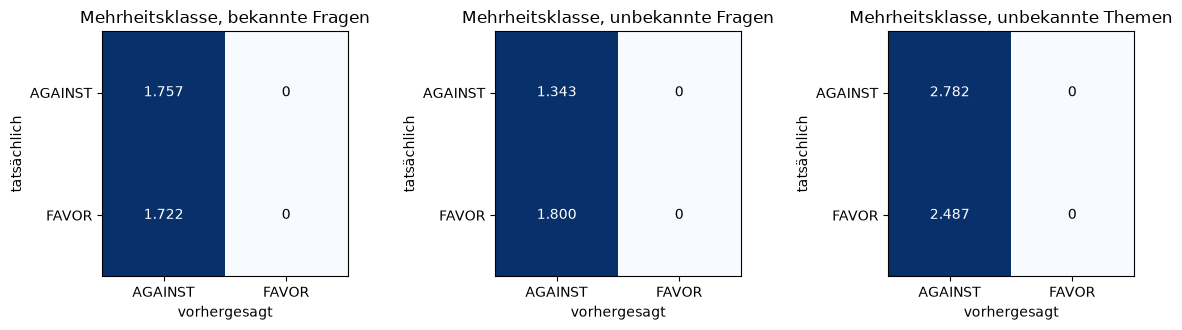

In [15]:
plot_confusion('Mehrheitsklasse', pred_majority)

**Abbildung 1: Konfusionsmatrizen der Mehrheitsklasse**

Zeilen zeigen das tatsächliche, Spalten das vorhergesagte Label, die Farbe den Anteil an der Zeile. Alle 1.757, 1.343 und 2.782 AGAINST-Paare liegen richtig, alle 1.722, 1.800 und 2.487 FAVOR-Paare falsch.

### 3.3 TF-IDF mit linearer SVM

Das lineare Verfahren orientiert sich an der SVM der SemEval-Veranstalter aus Abschnitt 2 (Mohammad et al., 2016). Dort lernte allerdings je Ziel eine eigene SVM mit Wort-n-Grammen bis zu Trigrammen. Weil unbekannte Fragen keine Trainingsbeispiele haben, lernt hier eine einzige SVM über alle Fragen hinweg, wie in der gemeinsamen Variante, die bei SemEval schwächer abschnitt. Sie nutzt Wort-Uni- und Bigramme, die Wendungen wie *nicht zielführend* erfassen, und Zeichen-n-Gramme der Länge 2 bis 5 innerhalb von Wortgrenzen, die Flexion, Komposita und die Schweizer Schreibung mit *ss* statt *ß* abfangen. Sublineare Termfrequenz dämpft Wiederholungen, `min_df = 2` entfernt Merkmale aus nur einem Paar. Frage und Kommentar werden wie beim fastText-Referenzsystem zu einem Text verbunden (Vamvas und Sennrich, 2020). Die Frage wirkt damit bis auf Wort-Bigramme an der Nahtstelle nur additiv, nicht im Zusammenspiel mit dem Kommentar, und bei bekannten Fragen kann das Modell über ihre Wörter den Ja-Anteil jeder Frage lernen. Genau darin unterscheidet sich die SVM vom Satzpaar-Modell GBERT.

In [16]:
def pair_text(df):
    return (df['question'] + ' ' + df['comment']).tolist()  # Frage und Kommentar als ein Text

def make_features():
    return make_union(TfidfVectorizer(analyzer='word', ngram_range=(1, 2), sublinear_tf=True, min_df=2),
                      TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), sublinear_tf=True, min_df=2))

features = make_features().fit(pair_text(train))  # Vokabular nur aus der Trainingsstichprobe
X_train = features.transform(pair_text(train))
X = {s: features.transform(pair_text(df)) for s, df in splits.items()}
print(f'{X_train.shape[1]:,} Merkmale, {X_train.shape[0]:,} Trainingspaare')

132,829 Merkmale, 16,911 Trainingspaare


Das Vokabular entsteht nur aus der Trainingsstichprobe und umfasst 132.829 Merkmale. Validierung und Testsätze werden mit demselben Vokabular abgebildet; Wörter aus neuen Fragen, die im Training fehlen, fallen dabei weg. Der Regularisierungsparameter C wird auf einem Raster von 0,01 bis 3,0 nach Validierungs-Makro-F1 gewählt.

In [17]:
grid = []
for C in [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]:
    svm = LinearSVC(C=C, random_state=RANDOM_STATE).fit(X_train, train['label'])
    pred = svm.predict(X['dev'])
    grid.append({'C': C, 'Dev Makro-F1': f1_score(splits['dev']['label'], pred, average='macro'),
                 'Dev Mikro-F1': accuracy_score(splits['dev']['label'], pred)})
grid = pd.DataFrame(grid).set_index('C')
best_C = grid['Dev Makro-F1'].idxmax()  # einziges Auswahlkriterium: Dev Makro-F1
print(f'C nach Dev Makro-F1: {best_C}, nach Dev Mikro-F1: {grid["Dev Mikro-F1"].idxmax()}')
grid.round(4)

C nach Dev Makro-F1: 0.3, nach Dev Mikro-F1: 0.3


,Dev Makro-F1,Dev Mikro-F1
C,,
0.01,0.6694,0.6695
0.03,0.6879,0.6879
0.10,0.6980,0.6980
0.30,0.6994,0.6994
1.00,0.6973,0.6973
3.00,0.6910,0.6910


Das Maximum liegt bei C = 0,3 mit 0,6994. Für C zwischen 0,1 und 1,0 liegen die Werte mit 0,6973 bis 0,6994 dicht beieinander, die Wahl ist also unkritisch. Mikro-F1, also die Accuracy, nach der Vamvas und Sennrich (2020) ihre Hyperparameter wählen, führt zum selben C. Mit diesem C wird die SVM einmal auf den Testsätzen bewertet.

In [18]:
svm = LinearSVC(C=best_C, random_state=RANDOM_STATE).fit(X_train, train['label'])
pred_svm = {s: svm.predict(X[s]) for s in TESTS}  # Testsätze einmal bewertet
evaluate('TF-IDF-SVM', pred_svm)

Precision  Recall     F1  Support  richtig
Testsatz          Klasse                                              
bekannte Fragen   AGAINST       0.720   0.692  0.706     1757     1216
                  FAVOR         0.698   0.725  0.711     1722     1248
                  Makro-F1        NaN     NaN  0.708     3479     2464
unbekannte Fragen AGAINST       0.546   0.561  0.553     1343      753
                  FAVOR         0.665   0.652  0.658     1800     1173
                  Makro-F1        NaN     NaN  0.606     3143     1926
unbekannte Themen AGAINST       0.634   0.719  0.674     2782     2001
                  FAVOR         0.631   0.536  0.579     2487     1333
                  Makro-F1        NaN     NaN  0.627     5269     3334

Auf bekannten Fragen erreicht die SVM einen Makro-F1 von 0,708 bei fast gleichen F1-Werten für AGAINST und FAVOR, 0,706 und 0,711. Auf unbekannten Fragen fällt sie auf 0,606, auf unbekannten Themen auf 0,627, und der Verlust verteilt sich ungleich. Bei unbekannten Fragen leidet AGAINST, dort die seltenere Klasse, mit F1 0,553. Bei unbekannten Themen erkennt die SVM nur 1.333 von 2.487 FAVOR-Paaren, ein Recall von 0,536. Eine naheliegende, hier nicht geprüfte Erklärung ist, dass ihre Gewichte an Formulierungen bekannter Fragen hängen.

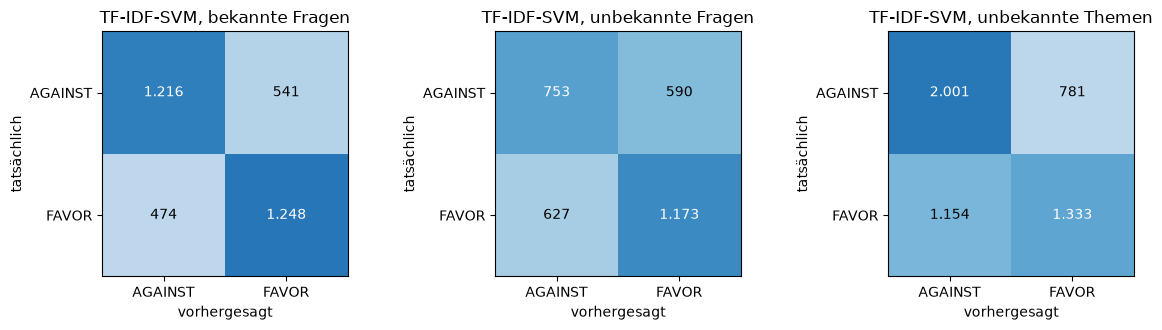

In [19]:
plot_confusion('TF-IDF-SVM', pred_svm)

**Abbildung 2: Konfusionsmatrizen der TF-IDF-SVM**

Auf bekannten Fragen verteilen sich die Fehler fast symmetrisch. Auf unbekannten Themen liegen 2.001 von 2.782 AGAINST-Paaren richtig, aber nur 1.333 von 2.487 FAVOR-Paaren.

Die veröffentlichten Systeme trainieren auf allen Daten. Um den Preis der halbierten Stichprobe abzuschätzen, trainiert die nächste Zelle dieselbe SVM mit demselben C einmal auf allen 33.850 deutschen Paaren. Das Ergebnis dient nur der Einordnung und fließt in keine Auswahl ein.

In [20]:
features_full = make_features().fit(pair_text(train_full))  # Sensitivität: alle 33.850 Paare
svm_full = LinearSVC(C=best_C, random_state=RANDOM_STATE).fit(features_full.transform(pair_text(train_full)), train_full['label'])
full = {TESTS[s]: f1_score(splits[s]['label'], svm_full.predict(features_full.transform(pair_text(splits[s]))), average='macro')
        for s in TESTS}
print('TF-IDF-SVM auf allen deutschen Trainingsdaten, Makro-F1:', {k: round(v, 3) for k, v in full.items()})
print('Gewinn gegenüber der Stichprobe in Punkten:', {TESTS[s]: round(100 * (full[TESTS[s]] - f1_score(splits[s]['label'], pred_svm[s], average='macro')), 1) for s in TESTS})

TF-IDF-SVM auf allen deutschen Trainingsdaten, Makro-F1: {'bekannte Fragen': 0.731, 'unbekannte Fragen': 0.628, 'unbekannte Themen': 0.632}
Gewinn gegenüber der Stichprobe in Punkten: {'bekannte Fragen': 2.3, 'unbekannte Fragen': 2.2, 'unbekannte Themen': 0.5}


Mit allen 33.850 Paaren steigt der Makro-F1 der SVM auf 0,731, 0,628 und 0,632, also um 2,3, 2,2 und 0,5 Punkte; bei unbekannten Themen bringt die doppelte Datenmenge kaum etwas. Damit liegt die SVM auf bekannten und unbekannten Fragen über fastText mit 69,9 und 62,0 und auf unbekannten Themen mit 63,1 gleichauf, in einem Lauf und ohne die französischen Daten, die fastText zusätzlich hatte. Für den Vergleich mit GBERT zählt weiterhin die SVM auf der Stichprobe.

### 3.4 Feinabgestimmtes GBERT

GBERT base ist ein deutsches BERT-Modell von deepset und der Bayerischen Staatsbibliothek München, vortrainiert mit Whole Word Masking, der Maskierung ganzer Wörter, auf OSCAR, OPUS, Wikipedia und Open Legal Data (Chan et al., 2020). Frage und Kommentar gehen als Satzpaar `[CLS] Frage [SEP] Kommentar [SEP]` ein, und eine lineare Schicht klassifiziert den letzten verborgenen Zustand des `[CLS]`-Tokens nach der Pooler-Schicht von BERT (Devlin et al., 2019), im Kern wie beim M-BERT-System von Vamvas und Sennrich (2020). Anders als die SVM kann das Modell so Wörter des Kommentars auf die Frage beziehen.

Batchgröße, Lernrate und Epochenzahl liegen im Bereich, den Devlin et al. (2019) für die Feinabstimmung angeben, der Weight Decay entspricht Schick und Schütze (2021). Die Einstellungen wurden nicht durch eine Suche bestimmt, weil jeder Lauf auf diesem Rechner Stunden kostet; aus demselben Grund fiel die Wahl auf GBERT base statt GBERT large. Trainiert wurde mit dem beiliegenden Skript `train_gbert.py` mit 4 CPU-Threads. Es speichert nach jeder Epoche die Wahrscheinlichkeiten für Validierung und Testsätze samt deren Makro-F1 in `data/cache/`, und das Notebook liest nur diesen Cache. Weil die Epochenzahl vorab feststand, konnten die mitgeschriebenen Testwerte keine Entscheidung beeinflussen.

In [21]:
protocol = json.loads((CACHE / 'protokoll_gbert.json').read_text())
for s, df in splits.items():
    assert (np.load(CACHE / f'ids_{s}.npy') == df['id'].to_numpy()).all()  # Reihenfolge wie im Cache
epochs = pd.DataFrame([{'Epoche': e['epoch'], 'Trainingsverlust': e['train_loss'], 'Minuten': e['train_seconds'] / 60,
                        'Dev Makro-F1': e['dev']['macro_f1'], 'Dev Mikro-F1': e['dev']['accuracy'],
                        **{f'{TESTS[s]} Makro-F1': e[s]['macro_f1'] for s in TESTS}} for e in protocol['epochs_log']])
rate = protocol['n_train'] * protocol['epochs'] / sum(e['train_seconds'] for e in protocol['epochs_log'])
print(f"{protocol['n_train']:,} Trainingspaare, lr {protocol['lr']}, Batch {protocol['batch']}, Warmup {protocol['warmup']}, "
      f"Weight Decay {protocol['weight_decay']}, max. {protocol['max_len']} Tokens, Seed {protocol['seed']}")
print(f"Laufzeit {protocol['total_seconds'] / 3600:.2f} h mit {protocol['threads']} CPU-Threads, einschließlich Auswertung; {rate:.1f} Trainingspaare pro Sekunde im Training")
epochs['Minuten'] = epochs['Minuten'].round(1)
epochs.set_index('Epoche').round(4)

16,911 Trainingspaare, lr 2e-05, Batch 16, Warmup 0.1, Weight Decay 0.01, max. 128 Tokens, Seed 1977
Laufzeit 2.64 h mit 4 CPU-Threads, einschließlich Auswertung; 6.2 Trainingspaare pro Sekunde im Training


,Trainingsverlust,Minuten,Dev Makro-F1,Dev Mikro-F1,bekannte Fragen Makro-F1,unbekannte Fragen Makro-F1,unbekannte Themen Makro-F1
Epoche,,,,,,,
1,0.6065,46.9,0.7287,0.7290,0.7330,0.7203,0.7174
2,0.4344,44.8,0.7491,0.7492,0.7528,0.7232,0.7326
3,0.2821,43.6,0.7544,0.7544,0.7654,0.7143,0.7262


Der Lauf dauerte einschließlich der Auswertung nach jeder Epoche 2,64 Stunden, das Training selbst lief mit 6,2 Trainingspaaren pro Sekunde; mit allen 33.850 Paaren hätte das Training etwa doppelt so lange gedauert. Der Validierungs-Makro-F1 steigt von 0,7287 über 0,7491 auf 0,7544, das Kriterium hätte also ebenfalls Epoche 3 gewählt. Die Testspalten dienen nur der Sensitivitätsanalyse. Die dritte Epoche verbessert unter den Testsätzen nur den Wert auf bekannten Fragen, von 0,7528 auf 0,7654, während unbekannte Fragen und Themen mit Epoche 2 bei 0,7232 und 0,7326 etwas höher lagen; die Epochen 1 und 2 sind dabei Zwischenstände eines Laufs mit linear fallender Lernrate, keine eigenen Läufe. Es gibt nur diesen einen Lauf mit Seed 1977, als Maßstab für die Streuung dienen die 0,4 bis 1,3 Punkte aus Abschnitt 2.

In [22]:
EPOCH = 3  # wie vorab festgelegt
proba_gbert = {s: np.load(CACHE / f'proba_gbert_ep{EPOCH}_{s}.npy') for s in splits}
pred_gbert = {s: np.array(LABELS)[proba_gbert[s].argmax(1)] for s in TESTS}
check = {s: round(f1_score(splits[s]['label'], pred_gbert[s], average='macro'), 4) for s in TESTS}
assert all(check[s] == protocol['epochs_log'][EPOCH - 1][s]['macro_f1'] for s in TESTS)  # Cache = Protokoll
evaluate('GBERT', pred_gbert)

Precision  Recall     F1  Support  richtig
Testsatz          Klasse                                              
bekannte Fragen   AGAINST       0.776   0.754  0.764     1757     1324
                  FAVOR         0.756   0.778  0.766     1722     1339
                  Makro-F1        NaN     NaN  0.765     3479     2663
unbekannte Fragen AGAINST       0.655   0.716  0.684     1343      961
                  FAVOR         0.772   0.719  0.745     1800     1294
                  Makro-F1        NaN     NaN  0.714     3143     2255
unbekannte Themen AGAINST       0.752   0.719  0.735     2782     2001
                  FAVOR         0.701   0.735  0.717     2487     1827
                  Makro-F1        NaN     NaN  0.726     5269     3828

GBERT erreicht einen Makro-F1 von 0,765, 0,714 und 0,726. Auf bekannten Fragen werden beide Klassen fast gleich gut erkannt, mit F1 0,764 für AGAINST und 0,766 für FAVOR. Die beiden Schwächen der SVM schrumpfen deutlich. Auf unbekannten Fragen steigt der F1-Wert für AGAINST von 0,553 auf 0,684, auf unbekannten Themen der Recall für FAVOR von 0,536 auf 0,735. AGAINST bleibt auf unbekannten Fragen die schwächere Klasse, mit einer Precision von 0,655.

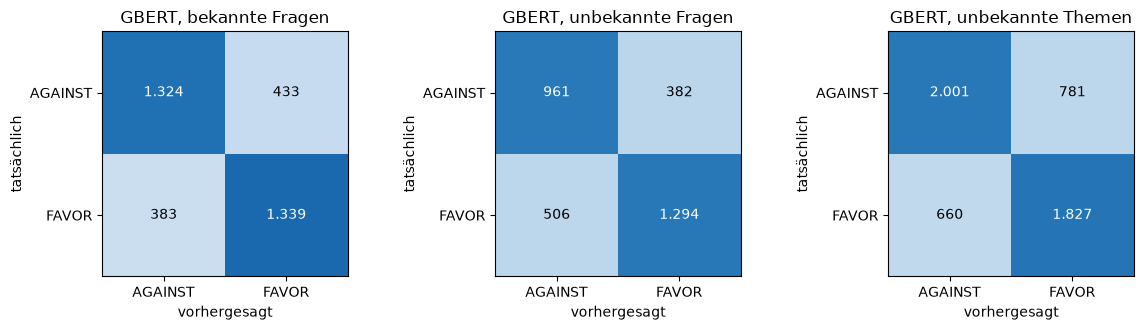

In [23]:
plot_confusion('GBERT', pred_gbert)

**Abbildung 3: Konfusionsmatrizen von GBERT, Epoche 3**

Auf unbekannten Themen liegen wie bei der SVM 2.001 von 2.782 AGAINST-Paaren richtig, von den 2.487 FAVOR-Paaren aber 1.827 statt 1.333.

### 3.5 Gesamtvergleich und Unsicherheit

Die folgende Zelle stellt Makro-F1 und Mikro-F1 der 3 Systeme auf allen Testsätzen nebeneinander. Sie berechnet außerdem die beiden Größen der Forschungsfrage, den Vorsprung von GBERT vor der SVM in Prozentpunkten und den Anteil dieses Vorsprungs, der auf unbekannten Fragen und Themen erhalten bleibt.

In [24]:
systems = {'Mehrheitsklasse': pred_majority, 'TF-IDF-SVM': pred_svm, 'GBERT': pred_gbert}
summary = pd.DataFrame({name: {f'{TESTS[s]} {m}': fn(splits[s]['label'], p[s]) for s in TESTS
                               for m, fn in [('Makro-F1', lambda y, q: f1_score(y, q, average='macro')), ('Mikro-F1', accuracy_score)]}
                        for name, p in systems.items()}).T
lead = {TESTS[s]: summary.loc['GBERT', f'{TESTS[s]} Makro-F1'] - summary.loc['TF-IDF-SVM', f'{TESTS[s]} Makro-F1'] for s in TESTS}
print('Vorsprung GBERT vor TF-IDF-SVM in Makro-F1-Punkten:', {k: round(100 * float(v), 1) for k, v in lead.items()})
print('davon erhalten gegenüber bekannten Fragen:', {k: round(float(v / lead['bekannte Fragen']), 2) for k, v in lead.items()})
summary.round(3)

Vorsprung GBERT vor TF-IDF-SVM in Makro-F1-Punkten: {'bekannte Fragen': 5.7, 'unbekannte Fragen': 10.9, 'unbekannte Themen': 9.9}
davon erhalten gegenüber bekannten Fragen: {'bekannte Fragen': 1.0, 'unbekannte Fragen': 1.9, 'unbekannte Themen': 1.74}


,bekannte Fragen Makro-F1,bekannte Fragen Mikro-F1,unbekannte Fragen Makro-F1,unbekannte Fragen Mikro-F1,unbekannte Themen Makro-F1,unbekannte Themen Mikro-F1
Mehrheitsklasse,0.336,0.505,0.299,0.427,0.346,0.528
TF-IDF-SVM,0.708,0.708,0.606,0.613,0.627,0.633
GBERT,0.765,0.765,0.714,0.717,0.726,0.727


GBERT übertrifft die SVM auf bekannten Fragen um 5,7 Prozentpunkte, auf unbekannten Fragen um 10,9 und auf unbekannten Themen um 9,9. Der Vorsprung schrumpft also nicht, er wächst, und der erhaltene Anteil liegt bei 1,9 und 1,74. Bei SVM und GBERT liegt der Mikro-F1 wegen der fast ausgeglichenen Klassen nah am Makro-F1. Bei der Mehrheitsklasse liegt er mit 0,505, 0,427 und 0,528 deutlich darüber, weil in ihren Makro-F1 der F1-Wert 0 der nie vorhergesagten Klasse FAVOR eingeht; die Rangfolge der Systeme ändert das nicht. Ob der Vorsprung über den Zufall der Testauswahl hinausgeht, zeigt die nächste Zelle.

In [25]:
rng = np.random.default_rng(RANDOM_STATE)
B = 2000  # Bootstrap-Stichproben je Testsatz und Ebene

def macro_f1_np(y, p):
    f = [2 * np.sum((y == c) & (p == c)) / max(np.sum(y == c) + np.sum(p == c), 1) for c in (0, 1)]
    return (f[0] + f[1]) / 2

def draws(s, level):
    if level == 'Paare':
        return [rng.integers(0, len(splits[s]), len(splits[s])) for _ in range(B)]
    groups = list(splits[s].groupby('question_id').indices.values())  # ganze Fragen ziehen
    return [np.concatenate([groups[g] for g in rng.integers(0, len(groups), len(groups))]) for _ in range(B)]

Y = {s: (splits[s]['label'] == 'FAVOR').to_numpy().astype(int) for s in TESTS}
P = {n: {s: (p[s] == 'FAVOR').astype(int) for s in TESTS} for n, p in systems.items() if n != 'Mehrheitsklasse'}
lead_b, rows = {}, {}
for level in ['Paare', 'Fragen']:
    for s in TESTS:
        idx = draws(s, level)
        f = {n: np.array([macro_f1_np(Y[s][i], P[n][s][i]) for i in idx]) for n in P}
        obs = macro_f1_np(Y[s], P['GBERT'][s]) - macro_f1_np(Y[s], P['TF-IDF-SVM'][s])
        lead_b[(s, level)] = f['GBERT'] - f['TF-IDF-SVM']
        ci = lambda v: f'[{np.percentile(v, 2.5):.3f}, {np.percentile(v, 97.5):.3f}]'
        share = lead_b[(s, level)] / lead_b[('new_comments', level)]
        rows[(level, TESTS[s])] = {'SVM 95%-KI': ci(f['TF-IDF-SVM']), 'GBERT 95%-KI': ci(f['GBERT']), 'Vorsprung': round(obs, 3),
                                   'Vorsprung 95%-KI': ci(lead_b[(s, level)]), 'p gepaart': np.mean(lead_b[(s, level)] > 2 * obs),
                                   'erhaltener Anteil 95%-KI': ci(share) if s != 'new_comments' else ''}
pd.DataFrame(rows).T

SVM 95%-KI    GBERT 95%-KI Vorsprung  \
Paare  bekannte Fragen    [0.694, 0.723]  [0.751, 0.779]     0.057   
       unbekannte Fragen  [0.588, 0.622]  [0.698, 0.730]     0.109   
       unbekannte Themen  [0.613, 0.640]  [0.714, 0.738]     0.099   
Fragen bekannte Fragen    [0.691, 0.723]  [0.750, 0.780]     0.057   
       unbekannte Fragen  [0.560, 0.635]  [0.673, 0.745]     0.109   
       unbekannte Themen  [0.590, 0.662]  [0.697, 0.756]     0.099   

                         Vorsprung 95%-KI p gepaart erhaltener Anteil 95%-KI  
Paare  bekannte Fragen     [0.040, 0.074]       0.0                           
       unbekannte Fragen   [0.088, 0.128]       0.0           [1.365, 2.833]  
       unbekannte Themen   [0.084, 0.115]       0.0           [1.274, 2.548]  
Fragen bekannte Fragen     [0.042, 0.074]       0.0                           
       unbekannte Fragen   [0.080, 0.150]       0.0           [1.249, 2.981]  
       unbekannte Themen   [0.066, 0.140]       0.0           [1.073, 2.711]

Die Intervalle von SVM und GBERT überschneiden sich auf keinem Testsatz, weder über Paare noch über Fragen gezogen. Über ganze Fragen gezogen reicht das Intervall des Vorsprungs für unbekannte Fragen von 0,080 bis 0,150 und für unbekannte Themen von 0,066 bis 0,140. Es ist breiter als über Paare, weil nur 14 und 20 Fragen gezogen werden. Keine der 2.000 Bootstrap-Differenzen übertrifft das Doppelte der beobachteten. Auch das Intervall des erhaltenen Anteils liegt beim Ziehen ganzer Fragen vollständig über 1, mit 1,249 bis 2,981 und 1,073 bis 2,711. Wie stark der Vorsprung wächst, ist also unsicher; dass er wächst, ist es bezogen auf die Auswahl der Testpaare und Testfragen nicht. Die Streuung zwischen Trainingsläufen erfasst der Bootstrap nicht, sie liegt nach Abschnitt 2 bei höchstens 1,3 Punkten.

In [26]:
disc = {}
for s in TESTS:
    y = splits[s]['label'].to_numpy()
    svm_ok, gbert_ok = pred_svm[s] == y, pred_gbert[s] == y
    disc[TESTS[s]] = {'beide richtig': int((svm_ok & gbert_ok).sum()), 'nur GBERT richtig': int((~svm_ok & gbert_ok).sum()),
                      'nur SVM richtig': int((svm_ok & ~gbert_ok).sum()), 'beide falsch': int((~svm_ok & ~gbert_ok).sum())}
pd.DataFrame(disc).T

,beide richtig,nur GBERT richtig,nur SVM richtig,beide falsch
bekannte Fragen,2128,535,336,480
unbekannte Fragen,1546,709,380,508
unbekannte Themen,2680,1148,654,787


Die Einzelfälle bestätigen das Bild. Auf unbekannten Fragen liegt GBERT in 709 Paaren richtig, in denen die SVM irrt, umgekehrt in 380; auf unbekannten Themen stehen 1.148 gegen 654. Auf bekannten Fragen ist das Verhältnis mit 535 zu 336 ausgeglichener.

### 3.6 Fehleranalyse

Die Fehleranalyse greift den vierten Befund aus Abschnitt 1.4 auf. Paare mit *eher ja* oder *eher nein* tragen dasselbe Label wie klare Antworten, und in 39 Fällen steht im Training derselbe Kommentar unter derselben Frage mit beiden Labels. Wenn diese Unschärfe zu den Fehlern beiträgt, müssten die schwachen Antwortstufen höhere Fehlerraten zeigen als die starken. Die Zelle gibt je Testsatz, System und ursprünglicher Antwortstufe den Anteil falsch klassifizierter Paare aus, die letzte Spalte teilt das Mittel der schwachen durch das Mittel der starken Stufen.

In [27]:
err = {}
for s in TESTS:
    df = splits[s]
    for sys_name, p in [('SVM', pred_svm[s]), ('GBERT', pred_gbert[s])]:
        wrong = pd.Series(p != df['label'].to_numpy())
        err[(TESTS[s], sys_name)] = wrong.groupby(df['numerical_label'].map(scale).to_numpy()).mean()
err = pd.DataFrame(err).T[list(scale.values())]
err['schwach / stark'] = (err['eher nein'] + err['eher ja']) / (err['nein'] + err['ja'])
err.round(3)

nein  eher nein  eher ja     ja  schwach / stark
bekannte Fragen   SVM    0.259      0.383    0.318  0.241            1.403
                  GBERT  0.175      0.356    0.268  0.186            1.730
unbekannte Fragen SVM    0.411      0.475    0.374  0.328            1.148
                  GBERT  0.258      0.317    0.322  0.249            1.259
unbekannte Themen SVM    0.264      0.307    0.509  0.428            1.178
                  GBERT  0.234      0.355    0.288  0.248            1.335

Die schwachen Stufen sind für beide Systeme schwerer. Bei GBERT liegt die Fehlerrate auf bekannten Fragen für *eher nein* bei 0,356, für *nein* bei 0,175. Das Verhältnis der Fehlerraten von schwachen zu starken Stufen beträgt bei GBERT 1,259 bis 1,730, bei der SVM 1,148 bis 1,403. Auf jedem Testsatz ist es bei GBERT höher, seine Fehler sammeln sich also stärker bei den Zwischentönen. Auf unbekannten Themen irrt GBERT bei *eher nein* mit 0,355 sogar häufiger als die SVM mit 0,307.

In [28]:
share = {}
for s in TESTS:
    df = splits[s]
    wrong = pred_gbert[s] != df['label'].to_numpy()
    weak = df['numerical_label'].isin([25, 75]).to_numpy()
    share[TESTS[s]] = {'GBERT-Fehler': int(wrong.sum()), 'davon schwache Antworten': int((wrong & weak).sum()),
                       'Anteil schwach an Fehlern': round((wrong & weak).sum() / wrong.sum(), 3),
                       'Anteil schwach im Testsatz': round(weak.mean(), 3)}
pd.DataFrame(share).T.astype({'GBERT-Fehler': int, 'davon schwache Antworten': int})

,GBERT-Fehler,davon schwache Antworten,Anteil schwach an Fehlern,Anteil schwach im Testsatz
bekannte Fragen,816,452,0.554,0.419
unbekannte Fragen,888,443,0.499,0.441
unbekannte Themen,1441,697,0.484,0.412


Schwache Antworten stellen einen Anteil von 0,484 bis 0,554 der GBERT-Fehler, aber nur von 0,412 bis 0,441 der Testpaare. Sie sind unter den Fehlern also überrepräsentiert, erklären aber nur einen Teil davon.

In [29]:
cue_err = {}
for s in TESTS:
    df = splits[s]
    has_cue = cue_word(df).notna().to_numpy()
    for sys_name, p in [('SVM', pred_svm[s]), ('GBERT', pred_gbert[s])]:
        wrong = p != df['label'].to_numpy()
        cue_err[(TESTS[s], sys_name)] = {'Fehlerrate mit Ja/Nein': round(wrong[has_cue].mean(), 3), 'n mit Ja/Nein': int(has_cue.sum()),
                                         'Fehlerrate ohne': round(wrong[~has_cue].mean(), 3), 'n ohne': int((~has_cue).sum())}
pd.DataFrame(cue_err).T.astype({'n mit Ja/Nein': int, 'n ohne': int})

Fehlerrate mit Ja/Nein  n mit Ja/Nein  \
bekannte Fragen   SVM                     0.124             97   
                  GBERT                   0.082             97   
unbekannte Fragen SVM                     0.163             86   
                  GBERT                   0.081             86   
unbekannte Themen SVM                     0.155            155   
                  GBERT                   0.052            155   

                         Fehlerrate ohne  n ohne  
bekannte Fragen   SVM              0.297    3382  
                  GBERT            0.239    3382  
unbekannte Fragen SVM              0.394    3057  
                  GBERT            0.288    3057  
unbekannte Themen SVM              0.374    5114  
                  GBERT            0.280    5114

Beginnt ein Kommentar mit Ja oder Nein, liegt die Fehlerrate von GBERT nur bei 0,052 bis 0,082, ohne ein solches Signalwort bei 0,239 bis 0,288. Die Gruppen mit Signalwort sind mit 86 bis 155 Paaren klein, der Abstand ist aber groß. Die eigentliche Schwierigkeit liegt bei Kommentaren ohne ein solches einleitendes Signalwort.

In [30]:
sub_authors = set(train['author'])  # Personen, die das Modell im Training gesehen hat
seen = {}
for s in ['new_questions', 'new_topics']:
    df = splits[s]
    known = df['author'].isin(sub_authors).to_numpy()
    for sys_name, p in [('SVM', pred_svm[s]), ('GBERT', pred_gbert[s])]:
        wrong = p != df['label'].to_numpy()
        seen[(TESTS[s], sys_name)] = {'Fehlerrate Person bekannt': round(wrong[known].mean(), 3), 'n bekannt': int(known.sum()),
                                      'Fehlerrate Person unbekannt': round(wrong[~known].mean(), 3), 'n unbekannt': int((~known).sum())}
pd.DataFrame(seen).T.astype({'n bekannt': int, 'n unbekannt': int})

Fehlerrate Person bekannt  n bekannt  \
unbekannte Fragen SVM                        0.389       2425   
                  GBERT                      0.277       2425   
unbekannte Themen SVM                        0.366       4125   
                  GBERT                      0.270       4125   

                         Fehlerrate Person unbekannt  n unbekannt  
unbekannte Fragen SVM                          0.380          718  
                  GBERT                        0.302          718  
unbekannte Themen SVM                          0.372         1144  
                  GBERT                        0.288         1144

Auf unbekannten Fragen und Themen irrt GBERT bei Personen aus der Trainingsstichprobe etwas seltener als bei neuen, 0,277 gegen 0,302 und 0,270 gegen 0,288; bei der SVM zeigt sich kein solcher Unterschied. Der in Befund 5 vermutete Vorteil bekannter Personen ist damit allenfalls angedeutet. Der Unterschied wurde nicht getestet, die Gruppen mit neuen Personen umfassen nur 718 und 1.144 Paare, und er ist in jedem Fall klein gegenüber dem Vorsprung von 10,9 und 9,9 Punkten. Die folgende Zelle zeigt die 5 Fehler auf unbekannten Themen, bei denen GBERT am sichersten war.

In [31]:
df = splits['new_topics'].assign(pred=pred_gbert['new_topics'], p=proba_gbert['new_topics'].max(1))
examples = df[df['pred'] != df['label']].sort_values('p', ascending=False).head(5)  # sicherste Fehlentscheidungen
pd.set_option('display.max_colwidth', 160)
examples[['question', 'comment', 'label', 'numerical_label', 'pred', 'p']].round(3)

,question,comment,label,numerical_label,pred,p
430,Würden Sie die Einführung der Widerspruchslösung bei der Organspende befürworten?,"Wir sind dringend auf die Spende von Organen angewiesen um Leben retten zu können. Ausserdem würde dies die Menschen zwingen, sich mit der Organspende ausei...",FAVOR,100,AGAINST,0.998
2458,Befürworten Sie die Senkung des Stimmrechtsalters auf 16 Jahre?,soll zuerst auf kommunaler und kantonaler Ebene erprobt werden,FAVOR,75,AGAINST,0.998
1487,Sollen sich die Versicherten stärker an den Gesundheitskosten beteiligen (z.B. Erhöhung der Mindestfranchise)?,Mehr Eigenverantwortung im Gesundheitswesen führt zu tieferen Kosten.,FAVOR,100,AGAINST,0.998
1215,Soll die Finanzierung von Parteien sowie von Wahl- und Abstimmungskampagnen offengelegt werden müssen?,Die Integrale Politik macht dies bereits freiwillig.,FAVOR,100,AGAINST,0.998
3735,"Sollen in der Schweiz vermehrt Spitäler geschlossen werden, um die Kosten im Gesundheitsbereich zu senken?","Ambulatorien in den Regionen und Gemeinschaftspraxen wären stattdessen zu fördern, die rasch, flexibel und kostengünstiger arbeiten.",FAVOR,75,AGAINST,0.998


Alle 5 sind FAVOR-Paare, die GBERT mit einer Wahrscheinlichkeit von 0,998 als AGAINST einstuft. Nur der Kommentar zur Organspende spricht die Zustimmung deutlich aus und ist ein klarer Modellfehler. Die Kommentare zur Franchise und zur Parteienfinanzierung stützen die Zustimmung nur indirekt, und die 2 Paare mit *eher ja* lesen sich eher als Einwand. Die Wahrscheinlichkeiten von GBERT taugen hier also nicht als Maß für seine Unsicherheit.

## 4 Kritische Reflexion und Fazit

### 4.1 Einordnung in den Stand der Technik

Die Tabelle stellt die eigenen Werte, umgerechnet auf die Skala von 0 bis 100, neben die Literatur. Die Zelle berechnet außerdem Vorsprung und erhaltenen Anteil für fastText und M-BERT auf dieselbe Weise wie Abschnitt 3.5 für SVM und GBERT.

In [32]:
training = {'Mehrheitsklasse': 'nur DE, 16.911 Paare', 'TF-IDF-SVM': 'nur DE, 16.911 Paare', 'GBERT': 'nur DE, 16.911 Paare, 128 Tokens'}
own = pd.DataFrame([{'System': name, 'Quelle': 'diese Arbeit', 'Training': training[name], 'Läufe': '1 Lauf',
                     **{TESTS[s]: round(100 * summary.loc[name, f'{TESTS[s]} Makro-F1'], 1) for s in TESTS}} for name in training])
own['Abfall unbekannte Fragen'] = (own['bekannte Fragen'] - own['unbekannte Fragen']).round(2)
own['Abfall unbekannte Themen'] = (own['bekannte Fragen'] - own['unbekannte Themen']).round(2)
table = pd.concat([literature, own], ignore_index=True).set_index(['System', 'Quelle'])
cols = list(TESTS.values())
lit = (table.loc[('M-BERT', 'Vamvas & Sennrich 2020'), cols] - table.loc[('fastText', 'Vamvas & Sennrich 2020'), cols]).astype(float)
print('M-BERT vor fastText in Punkten:', {k: round(float(v), 1) for k, v in lit.items()},  # Gegenstück zu GBERT vor SVM in 3.5
      '| erhaltener Anteil:', {k: round(float(v / lit['bekannte Fragen']), 2) for k, v in lit.items()})
table[cols + ['Abfall unbekannte Fragen', 'Abfall unbekannte Themen']].fillna('')  # Aufbau der Literatur siehe Abschnitt 2

M-BERT vor fastText in Punkten: {'bekannte Fragen': 6.9, 'unbekannte Fragen': 6.5, 'unbekannte Themen': 5.8} | erhaltener Anteil: {'bekannte Fragen': 1.0, 'unbekannte Fragen': 0.94, 'unbekannte Themen': 0.84}


,,bekannte Fragen,unbekannte Fragen,unbekannte Themen,Abfall unbekannte Fragen,Abfall unbekannte Themen
System,Quelle,,,,,
Mehrheitsklasse (global),Vamvas & Sennrich 2020,33.10,36.4,32.1,-3.3,1.0
Mehrheit je Frage,Vamvas & Sennrich 2020,60.80,,,,
fastText,Vamvas & Sennrich 2020,69.90,62.0,63.1,7.9,6.8
M-BERT,Vamvas & Sennrich 2020,76.80,68.5,68.9,8.3,7.9
"SVM, gehashte Merkmale",Egli et al. 2023,61.49,37.49,34.7,24.0,26.79
"XLM-R base, 4.000 Paare",Schick & Schütze 2021,63.20,,,,
XLM-R base,Schick & Schütze 2021,76.60,,,,
PET mit XLM-R base,Schick & Schütze 2021,77.90,,,,
"XLM-R base, DE+FR",Schick & Schütze 2021,77.60,,,,


Auf bekannten Fragen liegt GBERT mit 76,5 knapp unter M-BERT mit 76,8 und dem auf allen deutschen Daten trainierten XLM-R mit 76,6, sah dabei aber nur die Hälfte der deutschen Paare. PET und SwissBERT liegen mit 77,9 bis 78,8 darüber. Auf unbekannten Fragen und Themen liegt GBERT mit 71,4 und 72,6 über M-BERT mit 68,5 und 68,9, auf unbekannten Themen aber unter XLM-R und SwissBERT aus Vamvas et al. (2023) mit 73,0 und 74,0.

Deutlich verschieden ist der erhaltene Anteil. Zwischen fastText und M-BERT bleiben 0,94 und 0,84 des Vorsprungs erhalten, zwischen SVM und GBERT wächst er auf das 1,9- und 1,74-Fache. GBERT verliert beim Wechsel des Ziels nur 5,1 und 3,9 Punkte, M-BERT 8,3 und 7,9, die SVM aber 10,2 und 8,1. Plausibel ist, dass die SVM bei bekannten Fragen über die Wörter der Frage deren Ja-Anteil lernt; schon die Mehrheit je Frage erreicht 60,8. Bei neuen Fragen entfällt dieser Vorteil.

Die Vergleiche sind unscharf, denn gegenüber den stärksten Arbeiten habe ich halb so viele deutsche Paare und keine französischen genutzt, 128 statt 256 oder 512 Tokens, einen Lauf statt 3 oder 10 und ein deutsches Basismodell auf der CPU statt mehrsprachiger oder an Schweizer Texte angepasster Modelle auf Grafikkarten. Auf eine Hyperparametersuche verzichteten wie bei GBERT auch Schick und Schütze (2021) und Vamvas et al. (2023).

### 4.2 Schwierigkeiten und Grenzen

Die größte Schwierigkeit war die Rechenzeit. Ich habe bewusst auf der CPU eines eigenen Rechners trainiert, obwohl auch die Rechenserver der FH Südwestfalen oder ein Cloud-Dienst mit Grafikkarte möglich gewesen wären. Ein Lauf von GBERT kostete so 2,64 Stunden, und daran hängen die halbe Stichprobe, die 128 Tokens, der einzelne Seed und der Verzicht auf GBERT large. Damit ein abgebrochener Lauf nicht verloren geht, speichert das Skript Zwischenstände. Hinzu kamen die vertauschte Beschriftung und die 16 statt 14 Fragen im Artikel zum Datensatz sowie eine Recherche ohne Papers with Code.

3 Grenzen schränken das Ergebnis ein. Die erste ist der einzelne Lauf auf der Hälfte der Daten. Die in der Literatur berichtete Streuung zwischen Seeds von 0,4 bis 1,3 Punkten ist kleiner als jeder gemessene Vorsprung, doch die SVM gewinnt mit allen Daten bis zu 2,3 Punkte, und ob GBERT ähnlich zulegt, bleibt offen. Die zweite ist die Zusammensetzung der Testsätze, mit 0,573 FAVOR bei unbekannten Fragen, nur 14 und 20 Fragen und vielen bekannten Personen, bei denen GBERT etwas seltener irrt. Die dritte ist das Label selbst, die eigene Antwort der Person statt eines Urteils über den Text. Schwache Antworten stellen überproportional viele Fehler, und in 39 Fällen trägt derselbe Text unter derselben Frage beide Labels, sodass schon im Training kein Modell alle diese Paare richtig zuordnen kann.

### 4.3 Fazit

Gefragt war, um wie viele Prozentpunkte im Makro-F1 ein feinabgestimmtes GBERT eine TF-IDF-SVM bei Kommentaren zu bekannten Fragen übertrifft und welcher Anteil dieses Vorsprungs bei unbekannten Fragen und Themen erhalten bleibt. Auf bekannten Fragen sind es 5,7 Punkte. Auf unbekannten Fragen und Themen bleibt der Vorsprung nicht nur vollständig erhalten, er wächst auf 10,9 und 9,9 Punkte; der erhaltene Anteil liegt also bei 1,9 und 1,74, und auch im Bootstrap über ganze Fragen bleibt er über 1. Der Nutzen des vortrainierten Modells zeigt sich damit vor allem dort, wo eine neue Frage gestellt wird.

Über das Problem habe ich gelernt, dass ein guter Wert auf bekannten Fragen auch Wissen über die Fragen selbst enthalten kann, schon die Mehrheit je Frage erreicht 60,8, und deshalb nur begrenzt zeigt, wie gut ein Modell Kommentare zu neuen Fragen beurteilt. Für eine künftige Schweizer Wahl zählt vor allem der Testsatz mit unbekannten Fragen. Die Zwischentöne, die mir aus der landwirtschaftlichen Praxis vertraut sind, bleiben dabei auch für GBERT am schwierigsten.

## 5 Literatur

Berg-Kirkpatrick, T., Burkett, D. und Klein, D. (2012). An Empirical Investigation of Statistical Significance in NLP. In Proceedings of the 2012 Joint Conference on Empirical Methods in Natural Language Processing and Computational Natural Language Learning (EMNLP-CoNLL), S. 995-1005. Association for Computational Linguistics. https://aclanthology.org/D12-1091/

Chan, B., Schweter, S. und Möller, T. (2020). German's Next Language Model. In Proceedings of the 28th International Conference on Computational Linguistics (COLING 2020), S. 6788-6796. International Committee on Computational Linguistics. https://aclanthology.org/2020.coling-main.598/

Devlin, J., Chang, M.-W., Lee, K. und Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. In Proceedings of the 2019 Conference of the North American Chapter of the Association for Computational Linguistics: Human Language Technologies (NAACL-HLT), Band 1, S. 4171-4186. Association for Computational Linguistics. https://aclanthology.org/N19-1423/

Egli, E., Mamié, N., Müller, M. und Dolev, E. L. (2023). Voting Booklet Bias: Stance Detection in Swiss Federal Communication. arXiv-Preprint arXiv:2306.08999. https://arxiv.org/abs/2306.08999

Mohammad, S. M., Kiritchenko, S., Sobhani, P., Zhu, X. und Cherry, C. (2016). SemEval-2016 Task 6: Detecting Stance in Tweets. In Proceedings of the 10th International Workshop on Semantic Evaluation (SemEval-2016), S. 31-41. Association for Computational Linguistics. https://aclanthology.org/S16-1003/

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M. und Duchesnay, É. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research 12, S. 2825-2830. https://jmlr.org/papers/v12/pedregosa11a.html

Schick, T. und Schütze, H. (2021). Exploiting Cloze Questions for Few Shot Text Classification and Natural Language Inference. In Proceedings of the 16th Conference of the European Chapter of the Association for Computational Linguistics (EACL 2021), S. 255-269. Association for Computational Linguistics. https://aclanthology.org/2021.eacl-main.20

Vamvas, J. und Sennrich, R. (2020). X-stance: A Multilingual Multi-Target Dataset for Stance Detection. In Proceedings of the 5th Swiss Text Analytics Conference (SwissText) & 16th Conference on Natural Language Processing (KONVENS), CEUR Workshop Proceedings, Band 2624. https://ceur-ws.org/Vol-2624/paper9.pdf

Vamvas, J., Graën, J. und Sennrich, R. (2023). SwissBERT: The Multilingual Language Model for Switzerland. In Proceedings of the 8th edition of the Swiss Text Analytics Conference (SwissText 2023), S. 54-69. Association for Computational Linguistics. https://aclanthology.org/2023.swisstext-1.6/

Wolf, T., Debut, L., Sanh, V., Chaumond, J., Delangue, C., Moi, A., Cistac, P., Rault, T., Louf, R., Funtowicz, M., Davison, J., Shleifer, S., von Platen, P., Ma, C., Jernite, Y., Plu, J., Xu, C., Le Scao, T., Gugger, S., Drame, M., Lhoest, Q. und Rush, A. M. (2020). Transformers: State-of-the-Art Natural Language Processing. In Proceedings of the 2020 Conference on Empirical Methods in Natural Language Processing: System Demonstrations, S. 38-45. Association for Computational Linguistics. https://aclanthology.org/2020.emnlp-demos.6/

## Erklärung

Ich erkläre hiermit, dass ich die vorliegende Arbeit selbstständig verfasst und dabei keine anderen als die angegebenen Hilfsmittel benutzt habe. Sämtliche Stellen der Arbeit, die im Wortlaut oder dem Sinn nach Werken anderer Autoren entnommen sind, habe ich als solche kenntlich gemacht. Die Arbeit wurde bisher weder gesamt noch in Teilen einer anderen Prüfungsbehörde vorgelegt und auch noch nicht veröffentlicht.

28.09.2026

Yurii Dobrytsia